<a href="https://colab.research.google.com/github/RiShiKaRoRa22/AI_LAB/blob/main/ass7_resume_screening.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Install if needed
!pip install nltk scikit-learn pandas matplotlib

import pandas as pd
import numpy as np
import string
import nltk
import matplotlib.pyplot as plt

from nltk.corpus import stopwords
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

nltk.download('stopwords')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


True

In [14]:
data = {
    "Name": ["Amit", "Sarah", "Jay", "Ria", "Reuel", "Niha"],
    "Resume": [
        "Python machine learning data analysis SQL",
        "Deep learning NLP Python TensorFlow",
        "Java developer backend API development",
        "Python data science machine learning SQL",
        "Python Python Python Python machine learning",
        "Excel communication management"
    ],
    "Experience": [3, 2, 4, 1, 3, 5]
}

df = pd.DataFrame(data)
df.to_csv("resume_dataset.csv", index=False)

job_description = """Looking for a Data Scientist with skills in Python,
machine learning, data analysis, SQL, and deep learning."""

with open("job_description.txt", "w") as f:
    f.write(job_description)

# Display
print(df.head())
print("\nJob Description:\n", job_description)

    Name                                        Resume  Experience
0   Amit     Python machine learning data analysis SQL           3
1  Sarah           Deep learning NLP Python TensorFlow           2
2    Jay        Java developer backend API development           4
3    Ria      Python data science machine learning SQL           1
4  Reuel  Python Python Python Python machine learning           3

Job Description:
 Looking for a Data Scientist with skills in Python,
machine learning, data analysis, SQL, and deep learning.


In [15]:
stop_words = set(stopwords.words('english'))

def clean_text(text):
    text = text.lower()
    text = text.translate(str.maketrans('', '', string.punctuation))
    words = text.split()
    words = [w for w in words if w not in stop_words]
    return " ".join(words)

df["Cleaned_Resume"] = df["Resume"].apply(clean_text)
cleaned_jd = clean_text(job_description)

print("\nOriginal Resume:\n", df["Resume"][0])
print("\nCleaned Resume:\n", df["Cleaned_Resume"][0])


Original Resume:
 Python machine learning data analysis SQL

Cleaned Resume:
 python machine learning data analysis sql


In [16]:
skills = ["python", "machine", "learning", "data", "analysis",
          "sql", "deep", "nlp", "tensorflow", "java"]

def one_hot(text):
    return [1 if skill in text.split() else 0 for skill in skills]

jd_vec = one_hot(cleaned_jd)
resume_vecs = df["Cleaned_Resume"].apply(one_hot).tolist()

onehot_scores = []

for vec in resume_vecs:
    score = cosine_similarity([jd_vec], [vec])[0][0]
    onehot_scores.append(score)

df["OneHot_Score"] = onehot_scores

In [17]:
bow = CountVectorizer()
bow_matrix = bow.fit_transform([cleaned_jd] + df["Cleaned_Resume"].tolist())

bow_scores = cosine_similarity(bow_matrix[0:1], bow_matrix[1:]).flatten()
df["BoW_Score"] = bow_scores

print("\nVocabulary:", bow.get_feature_names_out())
print("Matrix Shape:", bow_matrix.shape)


Vocabulary: ['analysis' 'api' 'backend' 'communication' 'data' 'deep' 'developer'
 'development' 'excel' 'java' 'learning' 'looking' 'machine' 'management'
 'nlp' 'python' 'science' 'scientist' 'skills' 'sql' 'tensorflow']
Matrix Shape: (7, 21)


In [18]:
tfidf = TfidfVectorizer()
tfidf_matrix = tfidf.fit_transform([cleaned_jd] + df["Cleaned_Resume"].tolist())

tfidf_scores = cosine_similarity(tfidf_matrix[0:1], tfidf_matrix[1:]).flatten()
df["TFIDF_Score"] = tfidf_scores

# Ranking
df_sorted = df.sort_values(by="TFIDF_Score", ascending=False)

print("\nRanked Candidates:\n", df_sorted[["Name", "TFIDF_Score"]])


Ranked Candidates:
     Name  TFIDF_Score
0   Amit     0.716699
3    Ria     0.542782
4  Reuel     0.311754
1  Sarah     0.292386
2    Jay     0.000000
5   Niha     0.000000


In [19]:
filtered_df = df_sorted[df_sorted["Experience"] >= 2]
print("\nAfter Experience Filter:\n", filtered_df[["Name", "Experience"]])


After Experience Filter:
     Name  Experience
0   Amit           3
4  Reuel           3
1  Sarah           2
2    Jay           4
5   Niha           5


In [20]:
def length_filter(text):
    return 0 if len(text.split()) < 5 else 1

df["Valid_Length"] = df["Cleaned_Resume"].apply(length_filter)

df.loc[df["Valid_Length"] == 0, ["OneHot_Score", "BoW_Score", "TFIDF_Score"]] = 0

In [21]:
def skill_match(text):
    return sum([1 for skill in skills if skill in text.split()])

df["Skill_Match"] = df["Cleaned_Resume"].apply(skill_match)

final_df = df[df["Skill_Match"] >= 3]
print("\nAfter Skill Filter:\n", final_df[["Name", "Skill_Match"]])


After Skill Filter:
     Name  Skill_Match
0   Amit            6
1  Sarah            5
3    Ria            5
4  Reuel            3


In [22]:
print("\nKeyword Stuffing Candidate (Rahul):")
print(df[df["Name"] == "Rahul"][["BoW_Score", "TFIDF_Score"]])


Keyword Stuffing Candidate (Rahul):
Empty DataFrame
Columns: [BoW_Score, TFIDF_Score]
Index: []


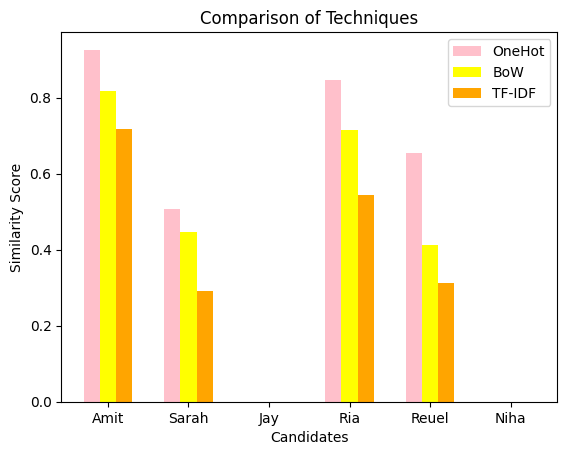

In [23]:
x = np.arange(len(df["Name"]))

plt.figure()
plt.bar(x - 0.2, df["OneHot_Score"], width=0.2, color='pink')
plt.bar(x, df["BoW_Score"], width=0.2, color='yellow')
plt.bar(x + 0.2, df["TFIDF_Score"], width=0.2, color='orange')

plt.xticks(x, df["Name"])
plt.xlabel("Candidates")
plt.ylabel("Similarity Score")
plt.title("Comparison of Techniques")
plt.legend(["OneHot", "BoW", "TF-IDF"])

plt.show()

In [24]:
comparison = df[["Name", "OneHot_Score", "BoW_Score", "TFIDF_Score"]]
comparison = comparison.sort_values(by="TFIDF_Score", ascending=False)

print("\nFinal Comparison Table:\n", comparison)


Final Comparison Table:
     Name  OneHot_Score  BoW_Score  TFIDF_Score
0   Amit      0.925820   0.816497     0.716699
3    Ria      0.845154   0.714435     0.542782
4  Reuel      0.654654   0.412479     0.311754
1  Sarah      0.507093   0.447214     0.292386
2    Jay      0.000000   0.000000     0.000000
5   Niha      0.000000   0.000000     0.000000
